In [2]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from math import floor
import random

In [3]:
class Hexagon:
    def __init__(self, geography, number, x, y, fig, ax, vertices=6, radius=0.1):
        self.geography=geography
        self.number=number
        self.x=x
        self.y=y
        self.vertices=vertices
        self.radius=radius
        self.ax = ax
        self.fig = fig
    
    def is_red_number(self):
        red_numbers=[6,8]
        if self.number in red_numbers:
            return True
        else:
            return False
    
    def draw_patch(self):
        self.draw_number()
        self.ax.add_patch(self.create_border())
        self.ax.add_patch(self.create_hexagon())
    
    def create_hexagon(self):
        return mpatches.RegularPolygon((self.x, self.y),
                                       self.vertices,
                                       radius=self.radius,
                                       color=self.set_color())
    
    def create_border(self):
        return mpatches.RegularPolygon((self.x, self.y),
                                       self.vertices,
                                       radius=self.radius*1.06,
                                       color="black")
    
    def draw_number(self):
        if self.is_red_number():
            col="red"
        else:
            col="black"
        self.ax.text(self.x, self.y-0.025, self.number, ha="center", family='sans-serif', size=20, color=col)
    
    def set_color(self):
        geo_to_color = {
            "sea": "skyblue",
            "hills": "sienna",
            "pastures": "lawngreen",
            "mountains": "darkgrey",
            "fields": "gold",
            "forests": "darkgreen",
            "gold_fields": "khaki",
            "desert": "moccasin"
        }
        
        return geo_to_color[self.geography]
    
    def none_tile(self):
        none_tiles = ["sea", "desert"]
        if self.geography in none_tiles:
            return True
        else:
            return False

In [4]:
class SumException(Exception):
    pass

In [5]:
class OddRowsException(Exception):
    pass

In [43]:
class Map:
    def __init__(self, rows, bases, seafarers, seed, geographies, numbers):
        self.rows=rows
        self.bases=bases
        self.seafarers=seafarers
        self.seed=seed
        self.geographies=geographies
        self.numbers=numbers
    
    def is_rows_odd(self):
        if self.rows % 2 == 0:
            raise OddRowsException("The number of desired rows is not odd! Please specify an odd number of rows.")
        elif self.rows % 2 == 1:
            return
    
    def main(self):
        self.is_rows_odd()
        self.draw_board()
    # Build the coordinates of each hexagon.
    def coordinates(self):
        coords = []
        switch_direction=floor(self.rows/2)
        hexagons_to_build=self.bases
        hex_x, hex_y = 0, 0.1
        row_start=0
        x_increment = 0.2
        y_increment = 0.168
        row_start_increment = 0.1
        
        for row in range(0, self.rows):
            for base in range(0, hexagons_to_build):
                coords.append((hex_x,hex_y))
                hex_x += x_increment
            hex_y += y_increment
            
            if row >= switch_direction:
                hexagons_to_build -= 1
                row_start += row_start_increment
            else:
                row_start -= row_start_increment
                hexagons_to_build += 1
            
            hex_x = row_start
            
        return coords
    
    def list_of_hexagons(self):
        fig, ax = plt.subplots()
        plt.axis('off')
        hexagons=[]
        list_of_geographies = self.add_n_from_dictionary(self.geographies)
        list_of_numbers = self.add_n_from_dictionary(self.numbers)
#         coords = [(0.2, 0.1), (0.38, 0.1), (0.56, 0.1), (0.74, 0.1), (0.9199999999999999, 0.1), (1.0999999999999999, 0.1), (1.28, 0.1), (1.46, 0.1), (0.11000000000000001, 0.26), (0.29000000000000004, 0.26), (0.47, 0.26), (0.65, 0.26), (0.83, 0.26), (1.01, 0.26), (1.1900000000000002, 0.26), (1.37, 0.26), (1.55, 0.26), (0.020000000000000018, 0.42000000000000004), (0.2, 0.42000000000000004), (0.38, 0.42000000000000004), (0.56, 0.42000000000000004), (0.74, 0.42000000000000004), (0.9199999999999999, 0.42000000000000004), (1.1, 0.42000000000000004), (1.28, 0.42000000000000004), (1.46, 0.42000000000000004), (1.64, 0.42000000000000004), (-0.07, 0.5800000000000001), (0.10999999999999999, 0.5800000000000001), (0.29, 0.5800000000000001), (0.47000000000000003, 0.5800000000000001), (0.6499999999999999, 0.5800000000000001), (0.8299999999999998, 0.5800000000000001), (1.01, 0.5800000000000001), (1.19, 0.5800000000000001), (1.3699999999999999, 0.5800000000000001), (1.5499999999999998, 0.5800000000000001), (1.7299999999999998, 0.5800000000000001), (0.01999999999999999, 0.7400000000000001), (0.19999999999999998, 0.7400000000000001), (0.38, 0.7400000000000001), (0.56, 0.7400000000000001), (0.74, 0.7400000000000001), (0.9199999999999999, 0.7400000000000001), (1.1, 0.7400000000000001), (1.28, 0.7400000000000001), (1.46, 0.7400000000000001), (1.64, 0.7400000000000001), (0.10999999999999999, 0.9000000000000001), (0.29, 0.9000000000000001), (0.47, 0.9000000000000001), (0.65, 0.9000000000000001), (0.83, 0.9000000000000001), (1.0099999999999998, 0.9000000000000001), (1.19, 0.9000000000000001), (1.37, 0.9000000000000001), (1.5499999999999998, 0.9000000000000001), (0.2, 1.06), (0.38, 1.06), (0.56, 1.06), (0.74, 1.06), (0.9199999999999999, 1.06), (1.0999999999999999, 1.06), (1.28, 1.06), (1.46, 1.06)]
        coords = self.coordinates()
        
        # Get left most and right most x coordinates for seafarers.
        left_most_hex = min(coords, key=lambda t: t[0])[0]
        right_most_hex = max(coords, key=lambda t: t[0])[0]
    
        number_count = 0
        geography_count = 0
    
        for count, coordinate in enumerate(coords):
            x, y = coordinate[0], coordinate[1]
            
            geography = list_of_geographies[geography_count]
            
            tile = Hexagon(geography, None, x, y, fig, ax)
            
            # Add left and right most sea tiles as per the seafarers board.
            if self.seafarers:
                if tile.x == left_most_hex or tile.x == right_most_hex:
                    tile.geography = "sea"
                    geography_count -= 1
            # Make sure number count doesn't increase when tile is None.
            if tile.none_tile():
                number_count -=1
            
            number = list_of_numbers[number_count]
            # If the geography is a tile without a number then set it to None.
            if tile.none_tile():
                number = None
            
            tile.number = number
            
            number_count += 1
            geography_count += 1
            
            hexagons.append(tile)
        return hexagons
    
    def draw_board(self):
        coords = self.coordinates()
        hexagons = self.list_of_hexagons()
        left_most_hex = min(coords, key=lambda t: t[0])[0] - 0.1
        right_most_hex = max(coords, key=lambda t: t[0])[0] + 0.1
        bottom_most_hex = min(coords, key=lambda t: t[1])[1] - 0.12
        top_most_hex = max(coords, key=lambda t: t[1])[1] + 0.12
        
        plt.xlim([left_most_hex, right_most_hex])
        plt.ylim([bottom_most_hex, top_most_hex])
        for hexagon in hexagons:
            hexagon.draw_patch()
    
    def add_n_from_dictionary(self, dictionary):
        randomised_list = []
        for item in dictionary:
            for i in range(0, dictionary[item]):
                randomised_list.append(item)
        random.shuffle(randomised_list)
        return randomised_list
    

In [7]:
default_geo = {"sea": 0,
             "desert": 1,
             "gold_fields": 0,
             "fields": 4,
             "hills": 3,
             "mountains": 3,
             "pastures": 4,
             "forests": 4}

default_num={2: 1,
             3: 2,
             4: 2,
             5: 2,
             6: 2,
             8: 2,
             9: 2,
             10: 2,
             11: 2,
             12: 1}

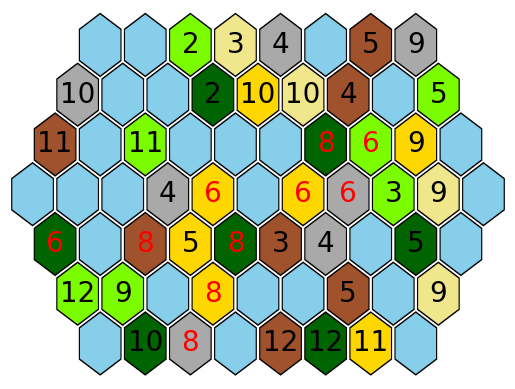

In [46]:
geography = {"sea": 24,
             "desert": 0,
             "gold_fields": 4,
             "fields": 7,
             "hills": 7,
             "mountains": 7,
             "pastures": 7,
             "forests": 7}
numbers={2: 2,
         3: 3,
         4: 4,
         5: 5,
         6: 5,
         8: 5,
         9: 5,
         10: 4,
         11: 3,
         12: 3}
Map(7, 8,True, 3004, geography, numbers).main()

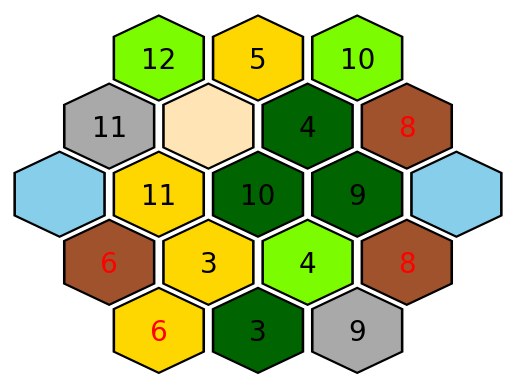

In [42]:
Map(5, 3,True, 3004, default_geo, default_num).draw_board()

In [10]:
Map(3,2,3,4,5,6).main()

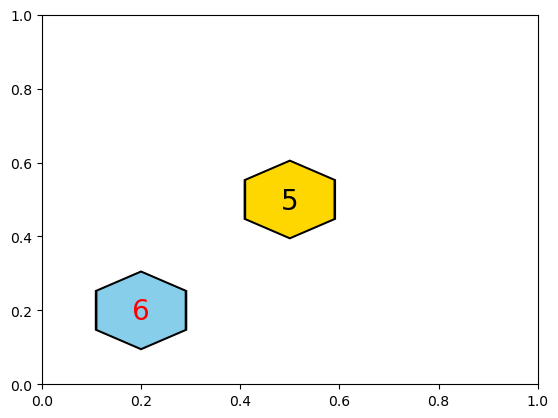

In [11]:
fig, ax = plt.subplots()
Hexagon("sea", 6, 0.2,0.2, fig, ax).draw_patch()
Hexagon("fields", 5, 0.5,0.5, fig, ax).draw_patch()